In [1]:
import os

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
import sys
sys.path.append('../src/')
from tqdm import tqdm
import warnings

from pyproj import CRS, Transformer
from geopy.distance import geodesic
from skgstat import Variogram, DirectionalVariogram

warnings.filterwarnings("ignore", message="Warning: converting a masked element to nan.")

import auxiliar_functions as aux

In [2]:
def create_grid(aoi, res=0.1):

    grid_xy = np.ogrid[aoi[0]:aoi[1]+res:res, aoi[2]:aoi[3]+res:res]
    grid_x, grid_y = grid_xy[0].reshape(1,-1)[0], grid_xy[1][0]
    coords = np.array([(i,j) for i in grid_x for j in grid_y])
    lon_rg, lat_rg = coords[:,0], coords[:,1]
    return lon_rg, lat_rg


def read_data(month, UNC_PATH, XCO2_PATH):
    uncertainties_1month = np.load(os.path.join(UNC_PATH, f'rg_uncert_{month}.npy'))
    
    #add cloud cover from xco2 to the months where it is missing
    if month in ["Mar", "Jun", "Jul"]:
        xco2_1month = np.load(os.path.join(XCO2_PATH, f'rg_xco2_{month}.npy'))
        uncertainties_1month[np.isnan(xco2_1month)] = np.nan
  
    return uncertainties_1month

Split along a longitude line

In [ ]:
date = 0
aoi = [-15, 40, 30, 60] 

west = False #which part to compute

monthid = 6

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

month = month_names[monthid]
DATA_PATH = '/home/pietaril/Documents/data/CO2M_simulations/regridded_monthly_uncertainties/'
uncertainties_1month = np.load(os.path.join(DATA_PATH, f'rg_uncert_{month}.npy'))

#add cloud cover from xco2 to the months where it is missing
if monthid in [2, 5, 6]:
    XCO2_PATH = '/home/pietaril/Documents/data/CO2M_simulations/regridded_monthly_xco2/'
    xco2_1month = np.load(os.path.join(XCO2_PATH, f'rg_xco2_{month}.npy'))
    uncertainties_1month[np.isnan(xco2_1month)] = np.nan

uncertainties = uncertainties_1month
period = '1month'

# create regular grid with the coordinates for the gridded uncertainties
lon_rg, lat_rg = create_grid(aoi)

# save data to a pandas dataframe
data = {'lon': lon_rg, 
        'lat': lat_rg, 
        'uncertainties': uncertainties
        }
df = pd.DataFrame(data)

# remove rows with NaN values
df = df.dropna()

df.reset_index(drop=True, inplace=True)
df.sort_values(by=['lon', 'lat'], inplace=True)

#convert lon, lat to x, y in meters
# NOTE: the projection can be changed to the one that fits the region of interest
inProj = CRS("EPSG:4326") # WGS84
outProj = CRS("EPSG:3035")
transformer = Transformer.from_crs(inProj, outProj, always_xy=True)
x, y = transformer.transform(df["lon"].values, df["lat"].values)
# Add the x,y coordinates to the dataframe
df['x'] = x
df['y'] = y



In [4]:

# divide into east and west area
lonsplit= 5
dfeast = df[df['lon']>= lonsplit].copy()
dfeast.reset_index(drop=True, inplace=True)
dfwest = df[df['lon']< lonsplit].copy()
dfwest.reset_index(drop=True, inplace=True)


In [9]:
transformer.transform(35, 2)

(7343528.933648806, -1731363.8170203902)

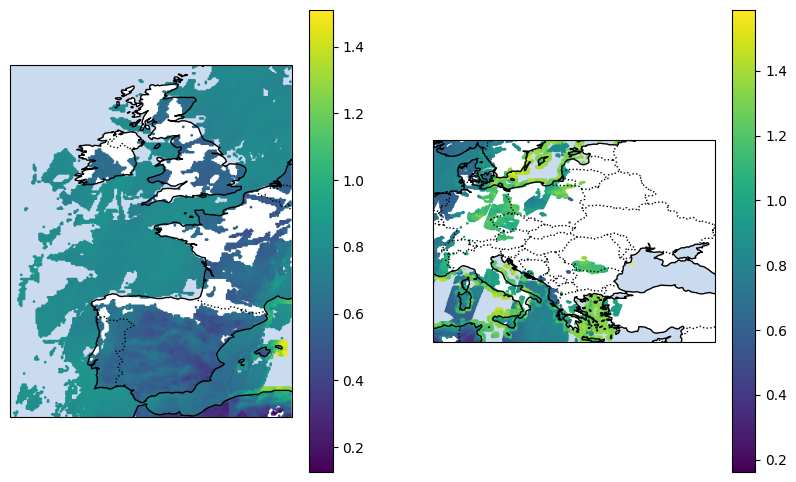

In [5]:
# check by plotting that the split worked as expected
import cartopy.feature as cfeature
import cartopy.crs as ccrs

aoi_west = [aoi[0],lonsplit, aoi[2], aoi[3]]
aoi_east = [lonsplit, aoi[1], aoi[2], aoi[3]]
aois = [aoi_west, aoi_east]
dfs = [dfwest, dfeast]


fig, axs = plt.subplots(1, 2, figsize=(10,6), subplot_kw={'projection': ccrs.PlateCarree()})

for i in range(2):
    
    # Add map features like coastlines, borders, and oceans
    axs[i].add_feature(cfeature.COASTLINE)
    axs[i].add_feature(cfeature.BORDERS, linestyle=':')
    axs[i].add_feature(cfeature.OCEAN, alpha=0.5)

    #bounds = gdf.geometry.total_bounds
    axs[i].set_extent(aois[i], crs=ccrs.PlateCarree())

    # plot uncertainties
    im = axs[i].scatter(dfs[i]['lon'], dfs[i]['lat'], c=dfs[i]['uncertainties'], cmap='viridis', transform=ccrs.PlateCarree(), s=0.85, alpha=1)
    plt.colorbar(im)
plt.show()

In [6]:
# calculate maximum distance of the partial aoi
if west == True:
    southwest_corner = (dfwest['lat'].values.min(), dfwest['lon'].min())  # (min_lat, min_lon)
    northeast_corner = (dfwest['lat'].values.max(), dfwest['lon'].values.max())  # (max_lat, max_lon)
    max_extent = geodesic(southwest_corner, northeast_corner).meters
else:

    southwest_corner = (dfeast['lat'].values.min(), dfeast['lon'].min())  # (min_lat, min_lon)
    northeast_corner = (dfeast['lat'].values.max(), dfeast['lon'].values.max())  # (max_lat, max_lon)
    max_extent = geodesic(southwest_corner, northeast_corner).meters
print(f'{max_extent/1000} km')

3306.175002152766 km


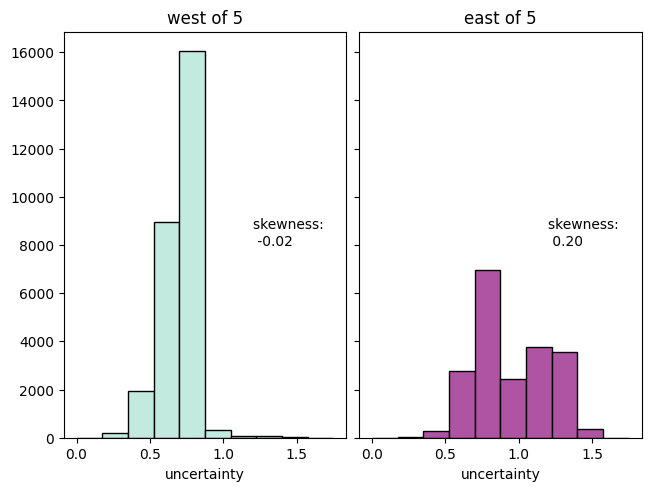

In [47]:
from scipy.stats import skew

fig, axs = plt.subplots(1, 2, layout="constrained", sharey=True)
title = [f"west of {lonsplit}", f"east of {lonsplit}"]
dfs = [dfwest, dfeast]

for i in range(2):
    uncs = dfs[i].uncertainties
    if i == 0:
        _, bins, _ = axs[i].hist(uncs, color=np.random.rand(3,), range = [0., 1.75], edgecolor="black")
    else:
        _ = axs[i].hist(uncs, bins=bins, color=np.random.rand(3,), edgecolor = "black")
    axs[i].set_title(title[i])
    axs[i].set_xlabel("uncertainty")

    axs[i].text(1.2, 8000, f"skewness: \n {skew(uncs):.2f}")

Text(0, 0.5, 'uncertainty [ppm]')

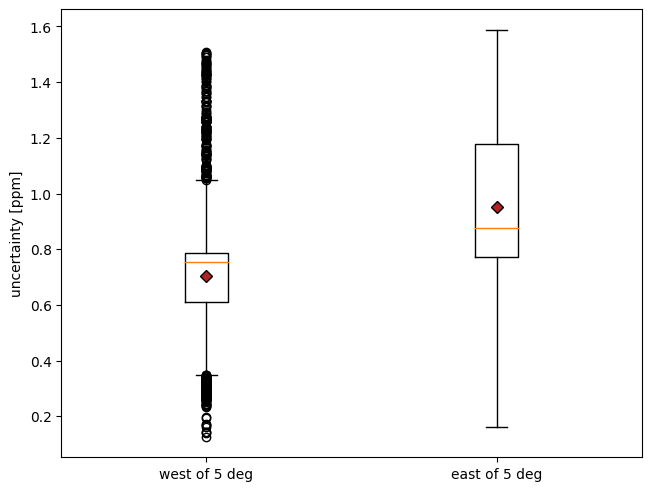

In [48]:
uncs = [dfwest.uncertainties, dfeast.uncertainties]

fig, ax = plt.subplots(layout="constrained")

labels = [f"west of {lonsplit} deg", f"east of {lonsplit} deg"]
colors = [np.random.rand(3,), np.random.rand(3,)]

meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor='firebrick')


plt.boxplot(uncs, meanprops=meanpointprops, meanline=False, showmeans=True) 
ax.set_xticklabels(labels)
ax.set_ylabel("uncertainty [ppm]")


In [11]:

# define the parameters for the variogram
model = 'stable'
maxlag = 800000 #800000 max_extent/3   500000
n_lags = 25


In [12]:
# calculate the empirical variogram
west = False

if west:
    coordinates = dfwest[['x', 'y']].values
    values = dfwest['uncertainties'].values
    domain = f"lon {aoi[0]}:{lonsplit}, lat {aoi[2]}:{aoi[3]}"
else:
    coordinates = dfeast[['x', 'y']].values  # x,y coordinates
    values = dfeast['uncertainties'].values  # variable of interest
    domain = f"lon {lonsplit}:{aoi[1]}, lat {aoi[2]}:{aoi[3]}"


estimator="matheron"
V = Variogram(coordinates, values, estimator=estimator, model=model, maxlag=maxlag, n_lags=n_lags)

In [9]:
print(V)

stable Variogram
----------------
Estimator:         matheron
Effective Range:   671048.18
Sill:              0.08
Nugget:            0.00
        


In [18]:
print(V.describe(flat=True))

{'model': 'stable', 'estimator': 'matheron', 'dist_func': 'euclidean', 'normalized_effective_range': 534054838080.07886, 'normalized_sill': 0.005734183499396412, 'normalized_nugget': 0, 'effective_range': 667568.550313942, 'sill': 0.07572439170700819, 'nugget': 0, 'shape': 1.4664148322788118, 'bin_func': 'even', 'normalize': False, 'fit_method': 'trf', 'fit_sigma': None, 'use_nugget': False, 'maxlag': 800000, 'n_lags': 25, 'verbose': False}


In [21]:
str(V.describe())

"{'model': 'stable', 'estimator': 'matheron', 'dist_func': 'euclidean', 'normalized_effective_range': 534054838080.07886, 'normalized_sill': 0.005734183499396412, 'normalized_nugget': 0, 'effective_range': 667568.550313942, 'sill': 0.07572439170700819, 'nugget': 0, 'shape': 1.4664148322788118, 'params': {'estimator': 'matheron', 'model': 'stable', 'dist_func': 'euclidean', 'bin_func': 'even', 'normalize': False, 'fit_method': 'trf', 'fit_sigma': None, 'use_nugget': False, 'maxlag': 800000, 'n_lags': 25, 'verbose': False}, 'kwargs': {}}"

/home/pietaril/.local/lib/python3.10/site-packages/skgstat/plotting/variogram_plot.py:123: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


Text(0.5, 1.0, 'Variogram Jul domain lon 5:40, lat 35:60')

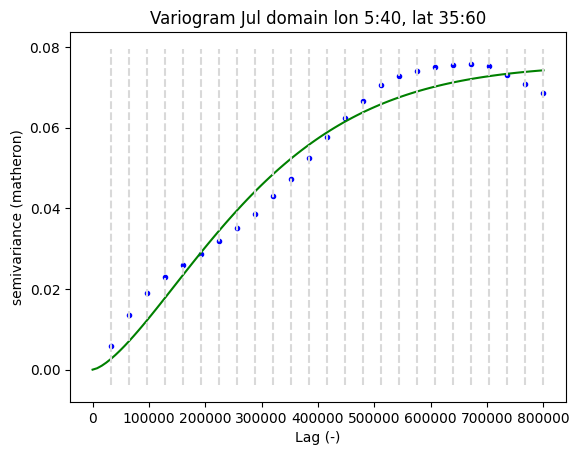

In [13]:
OUT_PATH = "/home/pietaril/Documents/plots/variogram_CO2M/"
#model = "spherical"
#V.model = model
# save and plot the variogram
fig, ax = plt.subplots()
V.plot(axes=ax)
ax.set_title(f"Variogram {month} domain {domain}")
# save in output path
# plt.savefig(f'{OUT_PATH}variogram_{month}_{domain}_{estimator}_{model}_{int(maxlag/1000)}km_{n_lags}_lags.png')
# plt.close()
# V.plot(axes=ax)


In [54]:
#min, mean and max differences within each group
for i, group in enumerate(V.lag_classes()):
    print('[Group %d]: elements: %d min %.2f, mean %.2f, max %.2f ' % (i, len(group), np.min(group), np.mean(group), np.max(group)))

[Group 0]: elements: 607918 min 0.00, mean 0.04, max 0.83 
[Group 1]: elements: 1773365 min 0.00, mean 0.06, max 0.98 
[Group 2]: elements: 2727175 min 0.00, mean 0.08, max 1.04 
[Group 3]: elements: 3760681 min 0.00, mean 0.09, max 1.16 
[Group 4]: elements: 4554950 min 0.00, mean 0.10, max 1.21 
[Group 5]: elements: 5424710 min 0.00, mean 0.11, max 1.24 
[Group 6]: elements: 6149949 min 0.00, mean 0.12, max 1.20 
[Group 7]: elements: 6731422 min 0.00, mean 0.13, max 1.17 
[Group 8]: elements: 7445071 min 0.00, mean 0.13, max 1.16 
[Group 9]: elements: 7858488 min 0.00, mean 0.14, max 1.24 
[Group 10]: elements: 8370164 min 0.00, mean 0.15, max 1.23 
[Group 11]: elements: 8781413 min 0.00, mean 0.15, max 1.22 
[Group 12]: elements: 9026622 min 0.00, mean 0.16, max 1.27 
[Group 13]: elements: 9393011 min 0.00, mean 0.16, max 1.31 
[Group 14]: elements: 9497394 min 0.00, mean 0.17, max 1.32 
[Group 15]: elements: 9678042 min 0.00, mean 0.17, max 1.30 
[Group 16]: elements: 9798511 min 0

In [55]:
print(V)

gaussian Variogram
------------------
Estimator:         matheron
Effective Range:   584002.31
Sill:              0.02
Nugget:            0.00
        


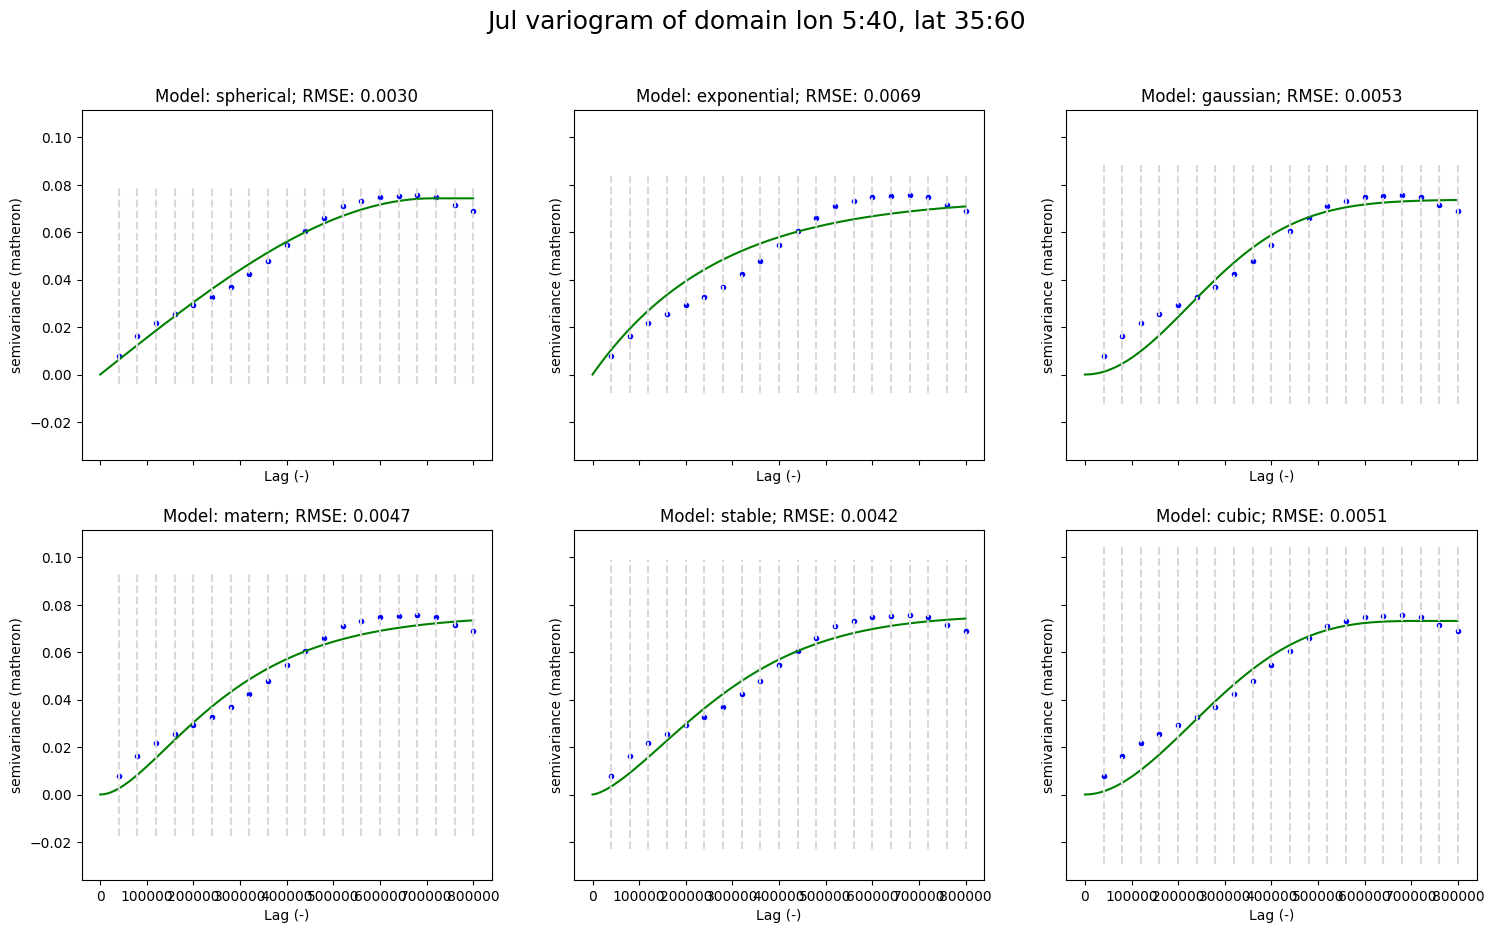

In [56]:
# visualization of the variograms for different models
fig, _a = plt.subplots(2,3, figsize=(18, 10), sharex=True, sharey=True)
axes = _a.flatten()
for i, model in enumerate(('spherical', 'exponential', 'gaussian', 'matern', 'stable', 'cubic')):
    V.model = model
    V.plot(axes=axes[i], hist=False, show=False)
    axes[i].set_title('Model: %s; RMSE: %.4f' % (model, V.rmse))
fig.suptitle(f"{month} variogram of domain {domain}", fontsize=18)
plt.savefig(f'{OUT_PATH}variogram_{month}_{domain}_{estimator}_comparison_{int(maxlag/1000)}km_{n_lags}_lags.png')
#plt.close()

# Version with domain split along a linear function

In [ ]:
# Define the linear function parameters: y = mx + b
m = 3  # slope
b = 34  # y-intercept

# Create the linear function line
line = m * df['lon'].values + b

# Create a mask for splitting the map
df_upper = df[df['lat']>= line]  # Points above the line
df_lower = df[df['lat'] < line]  # Points below the line

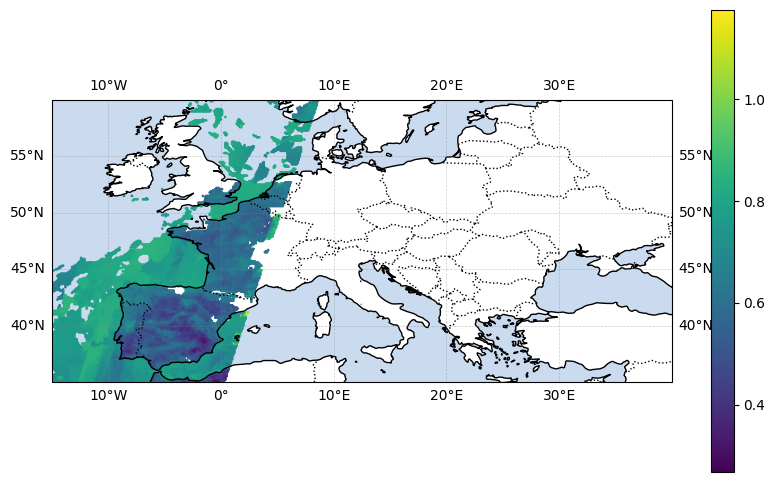

In [28]:
# check by plotting that the split worked as expected
import cartopy.feature as cfeature
import cartopy.crs as ccrs

fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection': ccrs.PlateCarree()})

# Add map features like coastlines, borders, and oceans
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.OCEAN, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.4, linestyle='--')

ax.set_extent(aoi, crs=ccrs.PlateCarree())

# plot uncertainties
im = ax.scatter(df_upper['lon'].values, df_upper['lat'].values, c=df_upper['uncertainties'], cmap='viridis', transform=ccrs.PlateCarree(), s=0.85, alpha=1)
plt.colorbar(im)



In [29]:
# calculate maximum distance of the partial aoi

dfs = [df_upper, df_lower]

for dfpart in dfs:

    southwest_corner = (dfpart['lat'].values.min(), dfpart['lon'].min())  # (min_lat, min_lon)
    northeast_corner = (dfpart['lat'].values.max(), dfpart['lon'].values.max())  # (max_lat, max_lon)
    max_extent = geodesic(southwest_corner, northeast_corner).meters
    print(f'{max_extent/1000} km')



3246.599906592073 km
3820.286885558636 km


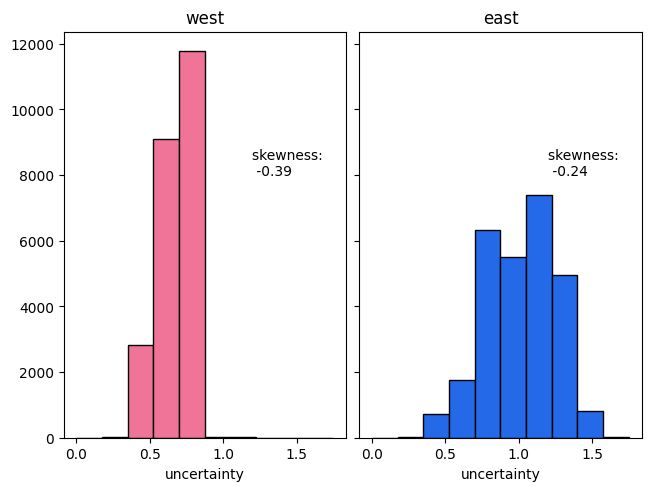

In [30]:
from scipy.stats import skew

fig, axs = plt.subplots(1, 2, layout="constrained", sharey=True)
title = [f"west", f"east"]


for i in range(2):
    uncs = dfs[i].uncertainties
    if i == 0:
        _, bins, _ = axs[i].hist(uncs, color=np.random.rand(3,), range = [0., 1.75], edgecolor="black")
    else:
        _ = axs[i].hist(uncs, bins=bins, color=np.random.rand(3,), edgecolor = "black")
    axs[i].set_title(title[i])
    axs[i].set_xlabel("uncertainty")

    axs[i].text(1.2, 8000, f"skewness: \n {skew(uncs):.2f}")

Text(0, 0.5, 'uncertainty [ppm]')

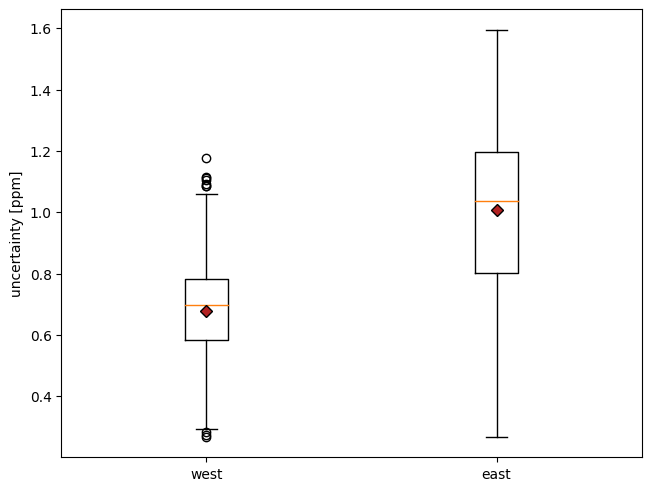

In [31]:
uncs = [df_upper.uncertainties, df_lower.uncertainties]

fig, ax = plt.subplots(layout="constrained")

labels = [f"west", f"east"]
colors = [np.random.rand(3,), np.random.rand(3,)]

meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor='firebrick')


plt.boxplot(uncs, meanprops=meanpointprops, meanline=False, showmeans=True) 
ax.set_xticklabels(labels)
ax.set_ylabel("uncertainty [ppm]")


In [ ]:
# calculate the empirical variogram

if west:
    coordinates = df_upper[['x', 'y']].values
    values = df_upper[['x', 'y']].values
    domain = f"lon {aoi[0]}:{lonsplit}, lat {aoi[2]}:{aoi[3]}"
else:
    coordinates = dfeast[['x', 'y']].values  # x,y coordinates
    values = dfeast['uncertainties'].values  # variable of interest
    domain = f"lon {lonsplit}:{aoi[1]}, lat {aoi[2]}:{aoi[3]}"


estimator="matheron"
V = Variogram(coordinates, values, estimator=estimator, model=model, maxlag=maxlag, n_lags=n_lags)